In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# import pandas as pd
# df = pd.read_csv('/content/drive/MyDrive/part_aa.csv')

In [3]:
# import pandas as pd

# chunksize = 10**6
# output_file = "/content/drive/MyDrive/purchase_cart_only.csv"

# first_chunk = True
# for chunk in pd.read_csv('/content/drive/MyDrive/2019-Oct.csv', chunksize=chunksize):
#     filtered = chunk[chunk['event_type'].isin(['cart', 'purchase'])]
#     # Append to file
#     filtered.to_csv(output_file, mode='a', header=first_chunk, index=False)
#     first_chunk = False


In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/purchase_cart_only.csv")
df.shape

(1669365, 9)

In [6]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:02:14 UTC,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,543272936,8187d148-3c41-46d4-b0c0-9c08cd9dc564
1,2019-10-01 00:04:37 UTC,purchase,1002532,2053013555631882655,electronics.smartphone,apple,642.69,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68
2,2019-10-01 00:05:14 UTC,cart,5100816,2053013553375346967,NaN,xiaomi,29.51,550121407,6f623695-9581-4633-813f-825b8760c7ae
3,2019-10-01 00:06:02 UTC,purchase,5100816,2053013553375346967,NaN,xiaomi,29.51,514591159,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56
4,2019-10-01 00:07:07 UTC,purchase,13800054,2053013557418656265,furniture.bathroom.toilet,santeri,54.42,555332717,1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f


In [7]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_time,1669365,1106766,2019-10-26 11:45:01 UTC,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,1669365,2,cart,926516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,1669365.0,NaN,NaN,NaN,4695698.772968,7180845.381635,1000978.0,1004833.0,1005135.0,4804295.0,60500009.0
category_id,1669365.0,NaN,NaN,NaN,2054770191118748672.0,13046318747099994.0,2053013552226107648.0,2053013555631882752.0,2053013555631882752.0,2053013555631882752.0,2175419595093967616.0
category_code,1390214,121,electronics.smartphone,887783,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,1592254,2012,samsung,476145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,1669365.0,NaN,NaN,NaN,323.030812,350.735863,0.0,109.66,190.67,385.83,2574.07
user_id,1669365.0,NaN,NaN,NaN,535570695.714935,18378557.685647,264649825.0,516689581.0,534877319.0,553796162.0,566280291.0
user_session,1669363,910796,1978995d-aa3c-47c4-94bb-1e1eea9c9457,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669365 entries, 0 to 1669364
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     1669365 non-null  object 
 1   event_type     1669365 non-null  object 
 2   product_id     1669365 non-null  int64  
 3   category_id    1669365 non-null  int64  
 4   category_code  1390214 non-null  object 
 5   brand          1592254 non-null  object 
 6   price          1669365 non-null  float64
 7   user_id        1669365 non-null  int64  
 8   user_session   1669363 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 114.6+ MB


In [9]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,279151
brand,77111
price,0
user_id,0
user_session,2


In [5]:
df[["category_code", "brand"]] = df[["category_code", "brand"]].fillna("Unknown")

In [6]:
df.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,0
brand,0
price,0
user_id,0
user_session,2


In [7]:
df = df.dropna(subset = ['price', 'user_id', 'user_session'])

In [8]:
df.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,0
brand,0
price,0
user_id,0
user_session,0


In [9]:
df.duplicated().sum()

np.int64(28149)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [18]:
print("Date range:", df['event_time'].min(), "to", df['event_time'].max())

Date range: 2019-10-01 00:02:14 UTC to 2019-10-31 23:59:16 UTC


In [19]:
df['event_type'].value_counts()

,count
event_type,
cart,898441
purchase,742773


In [20]:
print("Min price:", df['price'].min())
print("Max price:", df['price'].max())

Min price: 0.0
Max price: 2574.07


In [21]:
print("Unique sessions:", df['user_session'].nunique())
print("Unique users:", df['user_id'].nunique())

Unique sessions: 910796
Unique users: 481458


In [12]:
sessions_cart = set(df.loc[df['event_type']=="cart", "user_session"])
sessions_purchase = set(df.loc[df['event_type']=="purchase", "user_session"])
len(sessions_purchase), len(sessions_cart)

(629560, 573097)

In [13]:
abandoned_sessions = sessions_cart - sessions_purchase
print("Abandoned rate:", len(abandoned_sessions)/len(sessions_cart)*100, "%")

Abandoned rate: 49.073019052621106 %


In [14]:
# User Funnel
funnel = df.groupby('user_session')['event_type'].apply(lambda x : set (x)).value_counts()
print(funnel)

KeyboardInterrupt: 

In [15]:
purchase_sessions = df.loc[df['event_type'] == 'purchase', 'user_session'].unique()

abandoned = df[(df['event_type']=='cart') & (~df['user_session'].isin(purchase_sessions))]
print(abandoned['category_code'].value_counts().head())

category_code
electronics.smartphone         219679
Unknown                         58859
electronics.audio.headphone     25922
electronics.video.tv            16877
appliances.kitchen.washer       10508
Name: count, dtype: int64


In [26]:
print(abandoned['brand'].value_counts().head())

brand
samsung    117428
apple       87309
xiaomi      55070
huawei      17009
Unknown     10400
Name: count, dtype: int64


Step 2: Labelling the rows

In [16]:
cart_df = df[df['event_type'] == 'cart'].copy()
purchase_df = df[df['event_type'] == 'purchase'][['user_session', 'product_id', 'event_time']].copy()

In [17]:
cart_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
2,2019-10-01 00:05:14 UTC,cart,5100816,2053013553375346967,Unknown,xiaomi,29.51,550121407,6f623695-9581-4633-813f-825b8760c7ae
6,2019-10-01 00:09:33 UTC,cart,1002524,2053013555631882655,electronics.smartphone,apple,515.67,524325294,0b74a829-f9d7-4654-b5b0-35bc9822c238
10,2019-10-01 00:11:00 UTC,cart,4804056,2053013554658804075,electronics.audio.headphone,apple,161.98,533624186,e5ac3caa-e6d5-4d6b-ae06-2c18cd9ca683
13,2019-10-01 02:17:59 UTC,cart,1004833,2053013555631882655,electronics.smartphone,samsung,174.76,536415846,685b5b42-f597-4a69-ab4c-ef96a30bc454
17,2019-10-01 02:19:36 UTC,cart,1005003,2053013555631882655,electronics.smartphone,huawei,258.21,513632293,f2cc68f7-39d1-4a50-9dcf-f2a0921bdfda


In [18]:
purchase_df.head()

,user_session,product_id,event_time
0,8187d148-3c41-46d4-b0c0-9c08cd9dc564,1004856,2019-10-01 00:02:14 UTC
1,3c80f0d6-e9ec-4181-8c5c-837a30be2d68,1002532,2019-10-01 00:04:37 UTC
3,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56,5100816,2019-10-01 00:06:02 UTC
4,1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f,13800054,2019-10-01 00:07:07 UTC
5,2af9b570-0942-4dcd-8f25-4d84fba82553,4804055,2019-10-01 00:09:26 UTC


In [19]:
cart_labeled = cart_df.merge(purchase_df, on=['user_session', 'product_id'],
                             how='left', suffixes=("", "_purchase"))

In [20]:
cart_labeled.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_time_purchase
0,2019-10-01 00:05:14 UTC,cart,5100816,2053013553375346967,Unknown,xiaomi,29.51,550121407,6f623695-9581-4633-813f-825b8760c7ae,NaN
1,2019-10-01 00:09:33 UTC,cart,1002524,2053013555631882655,electronics.smartphone,apple,515.67,524325294,0b74a829-f9d7-4654-b5b0-35bc9822c238,2019-10-01 00:10:08 UTC
2,2019-10-01 00:11:00 UTC,cart,4804056,2053013554658804075,electronics.audio.headphone,apple,161.98,533624186,e5ac3caa-e6d5-4d6b-ae06-2c18cd9ca683,NaN
3,2019-10-01 02:17:59 UTC,cart,1004833,2053013555631882655,electronics.smartphone,samsung,174.76,536415846,685b5b42-f597-4a69-ab4c-ef96a30bc454,NaN
4,2019-10-01 02:19:36 UTC,cart,1005003,2053013555631882655,electronics.smartphone,huawei,258.21,513632293,f2cc68f7-39d1-4a50-9dcf-f2a0921bdfda,2019-10-01 02:32:46 UTC


In [21]:
cart_labeled["valid_purchase"] = (
    cart_labeled["event_time_purchase"] > cart_labeled["event_time"]
)

In [22]:
cart_labeled.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_time_purchase,valid_purchase
0,2019-10-01 00:05:14 UTC,cart,5100816,2053013553375346967,Unknown,xiaomi,29.51,550121407,6f623695-9581-4633-813f-825b8760c7ae,NaN,False
1,2019-10-01 00:09:33 UTC,cart,1002524,2053013555631882655,electronics.smartphone,apple,515.67,524325294,0b74a829-f9d7-4654-b5b0-35bc9822c238,2019-10-01 00:10:08 UTC,True
2,2019-10-01 00:11:00 UTC,cart,4804056,2053013554658804075,electronics.audio.headphone,apple,161.98,533624186,e5ac3caa-e6d5-4d6b-ae06-2c18cd9ca683,NaN,False
3,2019-10-01 02:17:59 UTC,cart,1004833,2053013555631882655,electronics.smartphone,samsung,174.76,536415846,685b5b42-f597-4a69-ab4c-ef96a30bc454,NaN,False
4,2019-10-01 02:19:36 UTC,cart,1005003,2053013555631882655,electronics.smartphone,huawei,258.21,513632293,f2cc68f7-39d1-4a50-9dcf-f2a0921bdfda,2019-10-01 02:32:46 UTC,True


In [23]:
cart_labeled["label"] = cart_labeled["valid_purchase"].fillna(False).astype(int)

In [24]:
cart_labeled = cart_labeled.drop(columns=["event_time_purchase", "valid_purchase"])

In [25]:
print("Cart Events:", len(cart_df))
print("Labeled cart events:", len(cart_labeled))
print("\nLabel distribution:")
print(cart_labeled["label"].value_counts(normalize=True))

cart_labeled.head()

Cart Events: 898441
Labeled cart events: 989175

Label distribution:
label
0    0.502433
1    0.497567
Name: proportion, dtype: float64


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,label
0,2019-10-01 00:05:14 UTC,cart,5100816,2053013553375346967,Unknown,xiaomi,29.51,550121407,6f623695-9581-4633-813f-825b8760c7ae,0
1,2019-10-01 00:09:33 UTC,cart,1002524,2053013555631882655,electronics.smartphone,apple,515.67,524325294,0b74a829-f9d7-4654-b5b0-35bc9822c238,1
2,2019-10-01 00:11:00 UTC,cart,4804056,2053013554658804075,electronics.audio.headphone,apple,161.98,533624186,e5ac3caa-e6d5-4d6b-ae06-2c18cd9ca683,0
3,2019-10-01 02:17:59 UTC,cart,1004833,2053013555631882655,electronics.smartphone,samsung,174.76,536415846,685b5b42-f597-4a69-ab4c-ef96a30bc454,0
4,2019-10-01 02:19:36 UTC,cart,1005003,2053013555631882655,electronics.smartphone,huawei,258.21,513632293,f2cc68f7-39d1-4a50-9dcf-f2a0921bdfda,1


In [26]:
# Check for duplicate purchase records
duplicates_in_purchase = purchase_df.duplicated(subset=['user_session', 'product_id'], keep=False).sum()
print(f"Duplicate purchase key count: {duplicates_in_purchase}")


Duplicate purchase key count: 93741


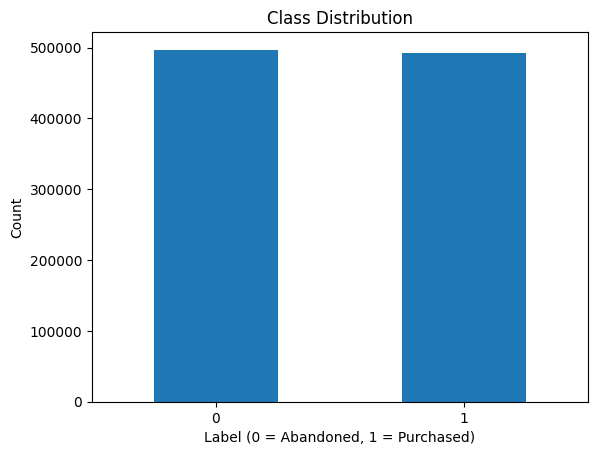

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
cart_labeled["label"].value_counts().plot(kind="bar", rot=0)
plt.title("Class Distribution")
plt.xlabel("Label (0 = Abandoned, 1 = Purchased)")
plt.ylabel("Count")
plt.show()

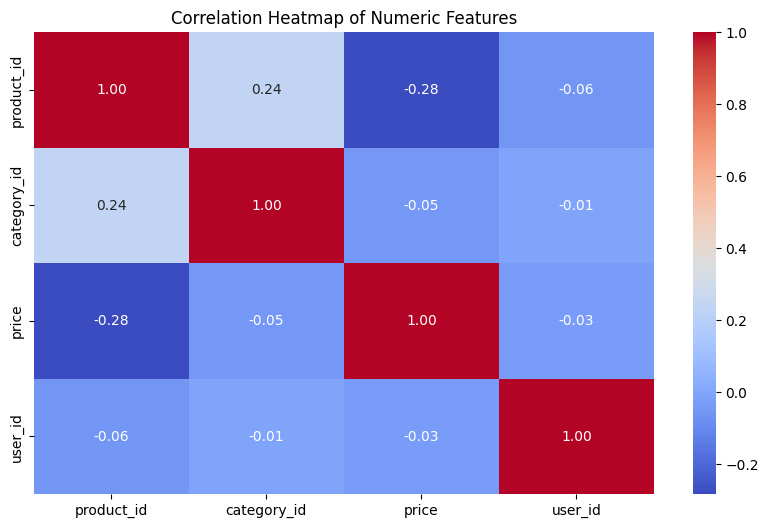

In [39]:
# Pick only numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr = numeric_cols.corr()

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [40]:
print("df columns:", df.columns.tolist())
print("cart_labeled columns:", cart_labeled.columns.tolist())

df columns: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']
cart_labeled columns: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session', 'label']


Feature Engineering

In [27]:
def build_features(df, cart_labeled):
    # Ensure event_time is datetime
    df["event_time"] = pd.to_datetime(df["event_time"], utc=True)
    cart_labeled["event_time"] = pd.to_datetime(cart_labeled["event_time"], utc=True)

    # Sort on session and time
    df = df.sort_values(["user_session", "event_time"])

    # Cumulative counts of views and carts
    df["cum_views"] = df.groupby("user_session")["event_type"].transform(lambda x: (x == "view").cumsum())
    df["cum_carts"] = df.groupby("user_session")["event_type"].transform(lambda x: (x == "cart").cumsum())

    # Time since session start
    df["session_start"] = df.groupby("user_session")["event_time"].transform("min")
    df["time_since_start"] = (df["event_time"] - df["session_start"]).dt.total_seconds()

    # Approximate unique products seen so far
    df["cum_unique_products"] = df.groupby("user_session").cumcount() + 1

    # print("df columns at merge time:", df.columns.tolist())

    # Merge once with labeled carts
    feature_df = cart_labeled.merge(
        df[
            ["event_time", "user_session", "cum_views", "cum_carts", "cum_unique_products", "time_since_start"]
        ],
        on=["user_session", "event_time"],
        how="left"
    )

    return feature_df[
    [
        "user_id",
        "event_time",
        "product_id",
        "price",
        "category_code",
        "brand",
        "cum_views",
        "cum_carts",
        "cum_unique_products",
        "time_since_start",
        "label",
    ]
]

In [28]:
feature_df = build_features(df, cart_labeled)

In [29]:
feature_df.shape

(989175, 11)

Step 3

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

ml_df = feature_df.copy()

ml_df = ml_df.drop(columns=["event_time"], errors="ignore")

In [45]:
for col in ['brand', 'category_code']:
  le = LabelEncoder()
  ml_df[col] = le.fit_transform(ml_df[col])

In [46]:
x = ml_df.drop(columns=["user_id", "label"])
y = ml_df["label"].astype(int)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

Train shape: (692422, 8) (692422,)
Test shape: (296753, 8) (296753,)


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

In [48]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

In [49]:
for name, model in  models.items():
  print(f"Training {name}...")
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test, y_pred)
  results[name] = acc
  print(f"{name} Accuracy: {acc:.4f}")
  print(classification_report(y_test, y_pred))
  print("-"*100)

Training Logistic Regression...
Logistic Regression Accuracy: 0.5453
              precision    recall  f1-score   support

           0       0.58      0.36      0.44    149098
           1       0.53      0.73      0.62    147655

    accuracy                           0.55    296753
   macro avg       0.55      0.55      0.53    296753
weighted avg       0.55      0.55      0.53    296753

----------------------------------------------------------------------------------------------------
Training Random Forest...
Random Forest Accuracy: 0.5514
              precision    recall  f1-score   support

           0       0.56      0.54      0.55    149098
           1       0.55      0.56      0.56    147655

    accuracy                           0.55    296753
   macro avg       0.55      0.55      0.55    296753
weighted avg       0.55      0.55      0.55    296753

----------------------------------------------------------------------------------------------------
Training Gradient 

In [50]:
# from sklearn.model_selection import RandomizedSearchCV

# # Optimized hyperparameter space for XGBoost
# param_dist = {
#     "n_estimators": [300, 500, 800],            # more trees for stability
#     "max_depth": [3, 5, 7],                     # deeper trees = more complex patterns
#     "learning_rate": [0.01, 0.05, 0.1],         # lower LR + more trees = better generalization
#     "subsample": [0.7, 0.8, 1.0],               # row sampling for regularization
#     "colsample_bytree": [0.7, 0.8, 1.0],        # feature sampling per tree
#     "min_child_weight": [1, 3, 5],              # controls leaf complexity
#     "gamma": [0, 1, 5],                         # min loss reduction (regularization)
#     "reg_lambda": [1, 5, 10],                   # L2 regularization
#     "reg_alpha": [0, 1, 5]                      # L1 regularization
# }

# xgb_search = RandomizedSearchCV(
#     estimator=models["XGBoost"],
#     param_distributions=param_dist,
#     n_iter=60,                   # 50–80 is fine, choose fixed
#     cv=3,                        # 3-fold cross-validation
#     scoring='recall',                # focus on Recall for class 1 (abandoners)
#     n_jobs=-1,                   # use all cores
#     verbose=2,
#     random_state=42               # reproducibility
# )

# xgb_search.fit(x_train, y_train)

# print("Best Params:", xgb_search.best_params_)
# print("Best CV Recall Score:", xgb_search.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best Params: {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 5, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV Recall Score: 0.6108566552306648


In [51]:
from sklearn.model_selection import cross_val_score
import numpy as np

# F1 score (balanced precision & recall)
f1_scores = cross_val_score(models["XGBoost"], x, y, cv=5, scoring='f1', n_jobs=-1)
print("F1 Mean:", np.mean(f1_scores))
print("F1 Std:", np.std(f1_scores))

# Recall (catch abandoners)
recall_scores = cross_val_score(models["XGBoost"], x, y, cv=5, scoring='recall', n_jobs=-1)
print("Recall Mean:", np.mean(recall_scores))
print("Recall Std:", np.std(recall_scores))

# Precision (don’t wrongly label buyers as abandoners)
precision_scores = cross_val_score(models["XGBoost"], x, y, cv=5, scoring='precision', n_jobs=-1)
print("Precision Mean:", np.mean(precision_scores))
print("Precision Std:", np.std(precision_scores))


F1 Mean: 0.5701986945336904
F1 Std: 0.022101303754378486
Recall Mean: 0.5841245204667693
Recall Std: 0.048536623032456004
Precision Mean: 0.559073541868408
Precision Std: 0.0030952666032995663


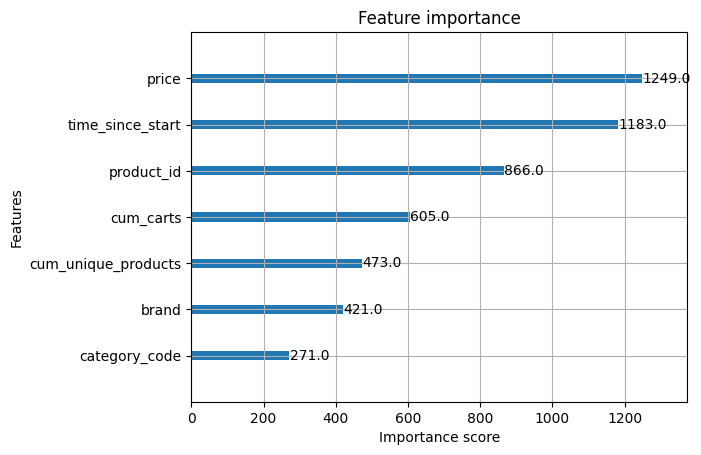

In [52]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(models['XGBoost'])
plt.show()

Code to paste abandoning users into gsheet

In [30]:
from google.colab import auth
import gspread
from gspread_dataframe import set_with_dataframe
from google.auth import default

auth.authenticate_user()

In [31]:
feature_df.shape

(989175, 11)

In [32]:
abandoners_df = feature_df[feature_df['label'] == 1].copy().astype(str)
abandoners_df.shape

(492181, 11)

In [39]:
abandoners_df = abandoners_df.drop_duplicates()

In [40]:
abandoners_df.duplicated().sum()

np.int64(0)

In [60]:
import gspread
from google.auth import default
import time

# Authenticate
creds, _ = default()
gc = gspread.authorize(creds)

SHEET_KEY = "1-rBtxAnKu0Lco7lpmJP_ZY21JUJCwVmIGITgK-w8rNs"
BASE_SHEET_NAME = "Sheet2"

def upload_dataframe_in_parts(df, sheet_key, base_sheet_name, batch_size=20000, max_rows_per_sheet=100000):
    sh = gc.open_by_key(sheet_key)
    total_rows = len(df)
    total_cols = df.shape[1]

    part_num = 1
    start_row = 0

    while start_row < total_rows:
        end_row = min(start_row + max_rows_per_sheet, total_rows)
        part_df = df.iloc[start_row:end_row]

        sheet_name = f"{base_sheet_name}_part{part_num}"
        try:
            worksheet = sh.worksheet(sheet_name)
            worksheet.clear()
            print(f"Using existing sheet: {sheet_name}")
        except gspread.WorksheetNotFound:
            worksheet = sh.add_worksheet(
                title=sheet_name, rows=str(max_rows_per_sheet+1), cols=str(total_cols)
            )
            print(f"Created new sheet: {sheet_name}")

        # Resize (safe, always under 50k rows)
        worksheet.resize(rows=len(part_df)+1, cols=total_cols)

        # Write headers
        worksheet.update("A1", [df.columns.tolist()])

        # Upload in batches
        local_start = 0
        while local_start < len(part_df):
            local_end = min(local_start + batch_size, len(part_df))
            batch = part_df.iloc[local_start:local_end].values.tolist()
            cell_range = f"A{local_start+2}"  # +2 for header

            success = False
            retries = 3
            while not success and retries > 0:
                try:
                    worksheet.update(cell_range, batch)
                    success = True
                    print(f"Uploaded rows {start_row+local_start} - {start_row+local_end} → {sheet_name}")
                except Exception as e:
                    print(f"Error at rows {start_row+local_start}-{start_row+local_end}: {e}")
                    retries -= 1
                    time.sleep(5)

            if not success:
                print(f"❌ Failed after retries at rows {start_row+local_start}-{start_row+local_end}. Exiting.")
                return

            local_start = local_end

        start_row = end_row
        part_num += 1

    print("✅ Upload completed across multiple sheets.")

# Run uploader
upload_dataframe_in_parts(abandoners_df, SHEET_KEY, BASE_SHEET_NAME)


Created new sheet: Sheet2_part1
Uploaded rows 0 - 20000 → Sheet2_part1
Uploaded rows 20000 - 40000 → Sheet2_part1
Uploaded rows 40000 - 60000 → Sheet2_part1
Uploaded rows 60000 - 80000 → Sheet2_part1
Uploaded rows 80000 - 100000 → Sheet2_part1
Created new sheet: Sheet2_part2
Uploaded rows 100000 - 120000 → Sheet2_part2
Uploaded rows 120000 - 140000 → Sheet2_part2
Uploaded rows 140000 - 160000 → Sheet2_part2
Uploaded rows 160000 - 180000 → Sheet2_part2
Uploaded rows 180000 - 200000 → Sheet2_part2
Created new sheet: Sheet2_part3
Uploaded rows 200000 - 220000 → Sheet2_part3
Uploaded rows 220000 - 240000 → Sheet2_part3
Uploaded rows 240000 - 260000 → Sheet2_part3
Uploaded rows 260000 - 280000 → Sheet2_part3
Uploaded rows 280000 - 300000 → Sheet2_part3
Created new sheet: Sheet2_part4
Uploaded rows 300000 - 320000 → Sheet2_part4
Uploaded rows 320000 - 340000 → Sheet2_part4
Uploaded rows 340000 - 360000 → Sheet2_part4
Uploaded rows 360000 - 380000 → Sheet2_part4
Uploaded rows 380000 - 400000 

Twilio Messaging Service

In [62]:
# pip install twilio

In [63]:
# from twilio.rest import Client

# SHEET_KEY = "1-rBtxAnKu0Lco7lpmJP_ZY21JUJCwVmIGITgK-w8rNs"
# SHEET_NAME = "Sheet2"

# worksheet = gc.open_by_key(SHEET_KEY).worksheet(SHEET_NAME)

# rows = worksheet.get_all_records()
# eg = pd.DataFrame(rows)
# eg.head()

Twilio config

In [64]:
# account_sid = 'AC4b7a0edf134e25493795425942995e19'
# auth_token = 'eecd6f7c7beb8ae0440e7e9aedacdf7d'
# client_twilio = Client(account_sid, auth_token)

In [65]:
# FROM_NUMBER="whatsapp:+14155238886"

# for row in rows:
#   name = row.get('name')
#   phone = str(row.get('phone'))
#   if not phone.startswith("+"):
#     phone = "+"+phone
#     # continue

#   msg =  f"Hey {name}, you left items in your cart 🛒. Here’s 20% off just for you 👉 https://yourshop.com/cart"
#   try:
#       message = client_twilio.messages.create(
#       from_=FROM_NUMBER,
#       body=msg,
#       to=f"whatsapp:{phone}"
#   )
#       print(f"Sent to {name} ({phone}), SID: {message.sid}")
#   except Exception as e:
#     print(f"Failed for {name} ({phone}): {e}")

Not Functional Now: Run its script from VS code

Streamlit Dashboard

In [66]:
# pip install streamlit

In [67]:
# import streamlit as st
# import random

# SHEET_KEY = "1-rBtxAnKu0Lco7lpmJP_ZY21JUJCwVmIGITgK-w8rNs"
# SHEET_NAME = "Sheet2"

# worksheet = gc.open_by_key(SHEET_KEY).worksheet(SHEET_NAME)
# data = worksheet.get_all_records()
# sdf = pd.DataFrame(data)
# sdf.shape

In [68]:
# st.write("Raw data from Google sheet:", sdf.head())
# st.write("Columns:", sdf.columns.tolist())

In [69]:
# # Synthetic recovery data, assume 30% recovery
# sdf['recovered'] = sdf['user_id'].apply(lambda x: random.choice([0,1,0,0,1]))

In [70]:
# total_abandoners = len(sdf)
# total_recovered = sdf['recovered'].sum()
# recovery_rate = (total_recovered / total_abandoners) *100 if total_abandoners > 0 else 0

In [71]:
# st.title("Cart Abandonment Dashboard")

# st.metric("Total Abandoners", total_abandoners)
# st.metric("Total recovered:", total_recovered)
# st.metric("Recovery rate %:", f"{recovery_rate:.2f}")

In [72]:
# st.subheader("Abandoners List")
# st.dataframe(sdf)

In [73]:
# sdf.columns.tolist()

In [74]:
# if 'event_time' in sdf.columns:
#     # ensure datetime conversion
#     sdf['event_time'] = pd.to_datetime(sdf['event_time'], errors='coerce')

#     # drop rows that failed to parse (optional)
#     sdf = sdf.dropna(subset=['event_time'])

#     # group by date
#     trend = sdf.groupby(sdf['event_time'].dt.date).size().reset_index(name='count')
#     trend = trend.rename(columns={'event_time': 'date'})  # clearer column name
#     trend = trend.sort_values("date")

#     st.subheader("Abandoners trend over time")
#     st.line_chart(trend.set_index("date"))
